<a href="https://colab.research.google.com/github/eren-boop/superstore-sales-analysis/blob/main/Superstore_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Superstore Sales Analysis

## Objective
Analyzed 9,994 orders from a retail Superstore dataset to understand sales
performance, profitability patterns, and regional trends using SQL, Python,
and statistical testing.

## Methodology
- **Data Cleaning:** Handled missing columns, converted date fields, verified
  data integrity (Pandas)
- **SQL Analysis:** Used SQL (via sqlite3) for aggregations, joins, and window
  functions (RANK, running totals)
- **Statistical Testing:** Applied T-tests and Chi-Square tests to validate
  business claims
- **Visualization:** Created trend and comparison charts (matplotlib)

## Key Findings
1. Technology category generates the highest average profit (₹78.75/order),
   while Furniture has the lowest (₹8.70/order) despite similar sales volume.
2. West region leads in both total sales (₹725K) and quantity sold (12,266 units).
3. Actual average discount (15.62%) is statistically higher than the claimed
   15% (p-value = 0.0027).
4. Sales show a clear upward trend from 2014–2017 with consistent seasonal
   spikes in Q4 (holiday season).
5. Region and Category showed no statistically significant relationship
   (Chi-Square p-value = 0.72) — sales patterns are consistent across regions.

## Recommendation
Furniture's low profit margin despite high sales volume suggests a need to
review pricing or discount strategy for this category. The Q4 seasonal spike
indicates an opportunity for targeted inventory planning ahead of the holiday season.

In [ ]:
import pandas as pd
df=pd.read_csv("SQL DATA.csv",encoding="latin1")
df=df.drop(columns=["Unnamed: 23","Unnamed: 24","Unnamed: 25","Unnamed: 26","Unnamed: 27"])
df.head()
print(df.shape)

(9994, 23)


In [ ]:
print("Shape:",df.shape)
print("Missing values:\n",df.isna().sum())
print("\n Duplicate rows:",df.duplicated().sum())
print("\n Data types:\n",df.dtypes)

Shape: (9994, 23)
Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
SALE CATEGORY    0
PROFIT STATUS    0
dtype: int64

 Duplicate rows: 0

 Data types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Disco

In [ ]:
df["Order date"]=pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"]=pd.to_datetime(df["Ship Date"], dayfirst=True)
print(df.dtypes[["Order date","Order date"]])
print(df.dtypes[["Ship Date","Ship Date"]])

Order date    datetime64[ns]
Order date    datetime64[ns]
dtype: object
Ship Date    datetime64[ns]
Ship Date    datetime64[ns]
dtype: object


In [ ]:
df["Order Date"]=pd.to_datetime(df["Order Date"],dayfirst=True)
print(df.dtypes[["Order Date","Ship Date"]])


Order Date    datetime64[ns]
Ship Date             object
dtype: object


In [ ]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'SALE CATEGORY', 'PROFIT STATUS']


In [ ]:
import pandas as pd
df=pd.read_csv("SQL DATA.csv",encoding="latin1")
df=df.drop(columns=["Unnamed: 23","Unnamed: 24","Unnamed: 25","Unnamed: 26","Unnamed: 27"])


In [ ]:
import sqlite3
conn=sqlite3.connect(":memory")
df.to_sql("orders",conn,index=False,if_exists="replace")
print("Database ready!")

Database ready!


In [ ]:
query="""
SELECT Region,sum(Sales) as Total_Sales FROM orders GROUP BY Region ORDER BY Total_Sales DESC"""
result=pd.read_sql(query,conn)
print(result)

    Region  Total_Sales
0     West  725457.8245
1     East  678781.2400
2  Central  501239.8908
3    South  391721.9050


In [ ]:
region_manager=pd.DataFrame({
    "Region":["Central","East","West",],
    "Manager_Name":["Amit Sharma","Priya Singh","Raj Verma"]
})
region_manager.to_sql("managers",conn,index=False,if_exists="replace")

3

In [ ]:
query2="""
SELECT orders.Region,orders.Sales,managers.Manager_Name FROM orders LEFT JOIN managers ON orders.Region=managers.Region LIMIT 10"""
result2=pd.read_sql(query2,conn)
print(result2)

  Region     Sales Manager_Name
0  South  261.9600         None
1  South  731.9400         None
2   West   14.6200    Raj Verma
3  South  957.5775         None
4  South   22.3680         None
5   West   48.8600    Raj Verma
6   West    7.2800    Raj Verma
7   West  907.1520    Raj Verma
8   West   18.5040    Raj Verma
9   West  114.9000    Raj Verma


In [ ]:
category_summary=df.groupby("Category").agg({"Sales":"sum","Profit":"mean"})
print(category_summary)


In [ ]:
region_segment=df.pivot_table(values="Profit",index="Region",columns="Segment",aggfunc="sum")
print(region_segment)

In [ ]:
from scipy import stats
t_stat1,p_value=stats.ttest_1samp(df["Discount"],0.15)
print("test1 -discount vs 15% claim:")
print("t-statistic",t_stat1,"| p-value:",p_value)

test1 -discount vs 15% claim:
t-statistic 3.003536659199256 | p-value: 0.0026752222518135237


In [ ]:
from scipy import stats
Furniture_profit=df[df["Category"]=="Furniture"]["Profit"]
Technology_profit=df[df["Category"]=="Technology"]["Profit"]
t_stat2,p_value2=stats.ttest_ind(Furniture_profit,Technology_profit)
print("\ntest 2-Furniture vs Technology profit:")
print("T-statistic:",t_stat2,"|p_value:",p_value2)


test 2-Furniture vs Technology profit:
T-statistic: -7.1232394903693965 |p_value: 1.246076188584697e-12


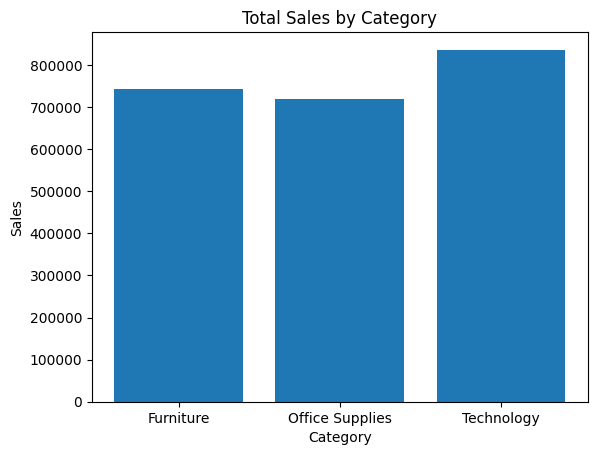

In [ ]:
import matplotlib.pyplot as plt
category_sales=df.groupby("Category")["Sales"].sum()
plt.bar(category_sales.index,category_sales.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

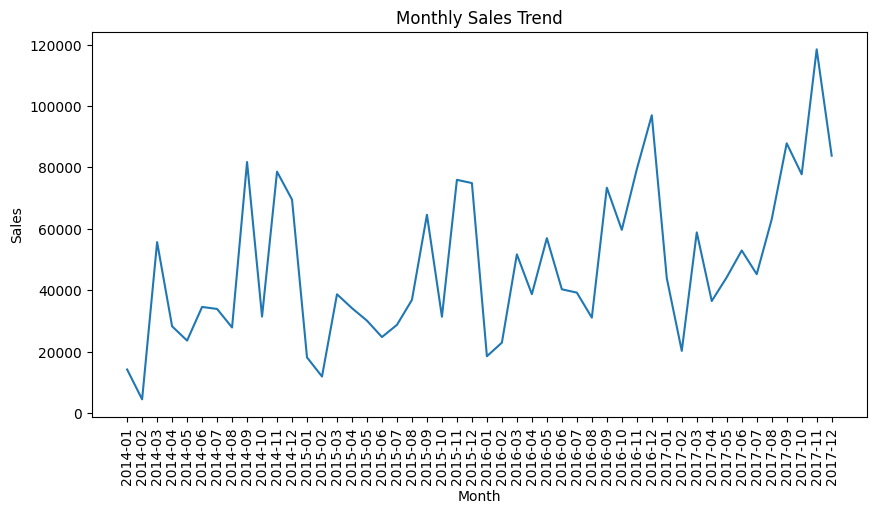

In [ ]:
df["Order Date"]=pd.to_datetime(df["Order Date"],dayfirst=True)
monthly_sales=df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index.astype(str),monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()